# Assignment 4 - Jazil's Notebook

In [13]:
print("Importing libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


Importing libraries...
All libraries imported successfully!


In [14]:
print("\n" + "="*60)
print("LOADING DATASET")
print("="*60)

# Load the dataset
df = pd.read_csv('cancer_reg.csv', encoding='latin-1')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Target variable: TARGET_deathRate")

# Display basic information
print("\n" + "="*50)
print("DATASET OVERVIEW")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("FIRST FEW ROWS")
print("="*50)
print(df.head())

# =============================================================================
# Check for missing values and basic statistics
# =============================================================================
print("\n" + "="*60)
print("DATA EXPLORATION")
print("="*60)

# Check for missing values
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df.describe())


LOADING DATASET
Dataset shape: (3047, 34)
Columns: ['avgAnnCount', 'avgDeathsPerYear', 'TARGET_deathRate', 'incidenceRate', 'medIncome', 'popEst2015', 'povertyPercent', 'studyPerCap', 'binnedInc', 'MedianAge', 'MedianAgeMale', 'MedianAgeFemale', 'Geography', 'AvgHouseholdSize', 'PercentMarried', 'PctNoHS18_24', 'PctHS18_24', 'PctSomeCol18_24', 'PctBachDeg18_24', 'PctHS25_Over', 'PctBachDeg25_Over', 'PctEmployed16_Over', 'PctUnemployed16_Over', 'PctPrivateCoverage', 'PctPrivateCoverageAlone', 'PctEmpPrivCoverage', 'PctPublicCoverage', 'PctPublicCoverageAlone', 'PctWhite', 'PctBlack', 'PctAsian', 'PctOtherRace', 'PctMarriedHouseholds', 'BirthRate']
Target variable: TARGET_deathRate

DATASET OVERVIEW
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avgAnnCount              3047 non-null   float64
 1   avgDeathsPerYear  

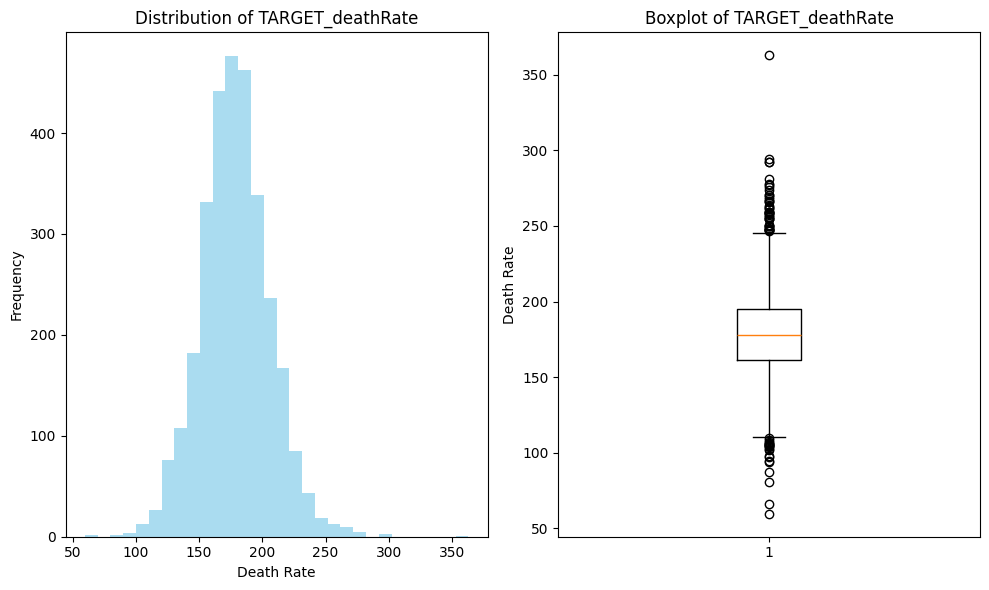

In [15]:
# Target variable distribution
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.hist(df['TARGET_deathRate'], bins=30, alpha=0.7, color='skyblue')
plt.title('Distribution of TARGET_deathRate')
plt.xlabel('Death Rate')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(df['TARGET_deathRate'])
plt.title('Boxplot of TARGET_deathRate')
plt.ylabel('Death Rate')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)

print("Handling missing values...")
df_cleaned = df.copy()

# Fill missing values with median for numerical columns
numerical_columns = df_cleaned.select_dtypes(include=[np.number]).columns
for col in numerical_columns:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)

# Fill missing values with mode for categorical columns
categorical_columns = df_cleaned.select_dtypes(include=['object']).columns
for col in categorical_columns:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)

print(f"Missing values after cleaning: {df_cleaned.isnull().sum().sum()}")


DATA PREPROCESSING
Handling missing values...
Missing values after cleaning: 0


In [17]:
# Remove the Geography column as it's not useful for modeling
if 'Geography' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop('Geography', axis=1)

# Remove the binnedInc column as it's redundant
if 'binnedInc' in df_cleaned.columns:
    df_cleaned = df_cleaned.drop('binnedInc', axis=1)

print(f"Final dataset shape: {df_cleaned.shape}")
print(f"Features: {list(df_cleaned.columns)}")

Final dataset shape: (3047, 32)
Features: ['avgAnnCount', 'avgDeathsPerYear', 'TARGET_deathRate', 'incidenceRate', 'medIncome', 'popEst2015', 'povertyPercent', 'studyPerCap', 'MedianAge', 'MedianAgeMale', 'MedianAgeFemale', 'AvgHouseholdSize', 'PercentMarried', 'PctNoHS18_24', 'PctHS18_24', 'PctSomeCol18_24', 'PctBachDeg18_24', 'PctHS25_Over', 'PctBachDeg25_Over', 'PctEmployed16_Over', 'PctUnemployed16_Over', 'PctPrivateCoverage', 'PctPrivateCoverageAlone', 'PctEmpPrivCoverage', 'PctPublicCoverage', 'PctPublicCoverageAlone', 'PctWhite', 'PctBlack', 'PctAsian', 'PctOtherRace', 'PctMarriedHouseholds', 'BirthRate']


In [18]:
X = df_cleaned.drop('TARGET_deathRate', axis=1)
y = df_cleaned['TARGET_deathRate']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Features shape: (3047, 31)
Target shape: (3047,)
Training set: 2437 samples
Test set: 610 samples


In [19]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing completed!")

Data preprocessing completed!


In [20]:
print("\n" + "="*60)
print("MODEL TRAINING")
print("="*60)

print("Training Random Forest model...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("Model training completed!")



MODEL TRAINING
Training Random Forest model...
Model training completed!


In [21]:
print("\n" + "="*60)
print("MODEL PERFORMANCE EVALUATION")
print("="*60)

# Training set metrics
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Training Set Metrics:")
print(f"  MSE: {train_mse:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  MAE: {train_mae:.2f}")
print(f"  R² Score: {train_r2:.4f}")


MODEL PERFORMANCE EVALUATION
Training Set Metrics:
  MSE: 50.12
  RMSE: 7.08
  MAE: 5.16
  R² Score: 0.9339


In [22]:
# Test set metrics
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nTest Set Metrics:")
print(f"  MSE: {test_mse:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  MAE: {test_mae:.2f}")
print(f"  R² Score: {test_r2:.4f}")


Test Set Metrics:
  MSE: 368.28
  RMSE: 19.19
  MAE: 14.09
  R² Score: 0.5499


In [23]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Most Important Features:")
print(feature_importance.head(10))


Top 10 Most Important Features:
                   feature  importance
17       PctBachDeg25_Over    0.220252
2            incidenceRate    0.204423
16            PctHS25_Over    0.047896
3                medIncome    0.043087
1         avgDeathsPerYear    0.037142
24  PctPublicCoverageAlone    0.033858
28            PctOtherRace    0.025943
5           povertyPercent    0.024503
20      PctPrivateCoverage    0.024444
26                PctBlack    0.022977



VISUALIZATIONS


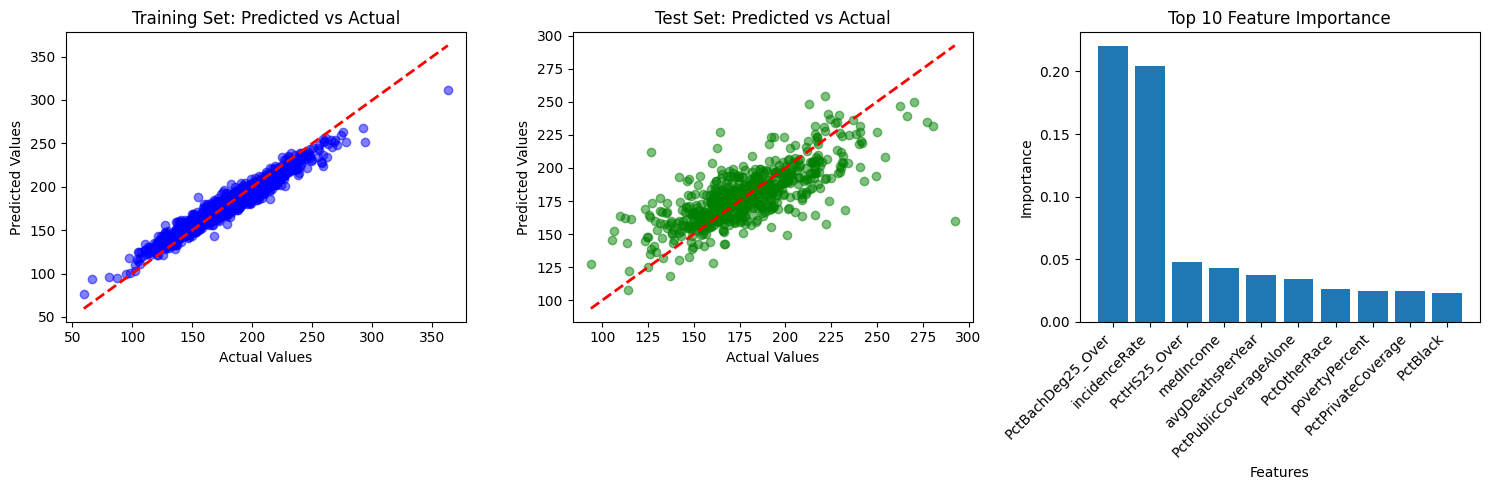

In [24]:
print("\n" + "="*60)
print("VISUALIZATIONS")
print("="*60)

# Visualize predictions vs actual values
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Training Set: Predicted vs Actual')

plt.subplot(1, 3, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Test Set: Predicted vs Actual')

plt.subplot(1, 3, 3)
plt.bar(range(len(feature_importance.head(10))), feature_importance.head(10)['importance'])
plt.xticks(range(len(feature_importance.head(10))), feature_importance.head(10)['feature'], rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Top 10 Feature Importance')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
print("\n" + "="*60)
print("MODEL MONITORING SETUP")
print("="*60)

print("Setting up basic model monitoring...")


# Store baseline metrics for comparison
baseline_metrics = {
    'mse': test_mse,
    'rmse': test_rmse,
    'mae': test_mae,
    'r2': test_r2
}

print("Baseline metrics stored for drift detection")


MODEL MONITORING SETUP
Setting up basic model monitoring...
Baseline metrics stored for drift detection


In [26]:
print("\n" + "="*60)
print("DATA DRIFT TESTING")
print("="*60)

def create_modified_test_data(X_test_original, scenario):
    """
    Create modified test data based on the specified scenario
    
    Args:
        X_test_original: Original test features
        scenario: String indicating which modifications to apply ('A', 'AB', 'ABC')
    
    Returns:
        Modified test features
    """
    X_test_modified = X_test_original.copy()
    
    if 'A' in scenario:
        # Scenario A: Decrease medianIncome by 40,000
        if 'medIncome' in X_test_modified.columns:
            X_test_modified['medIncome'] = X_test_modified['medIncome'] - 40000
            print(f"Applied Scenario A: Decreased medIncome by 40,000")
    
    if 'B' in scenario:
        # Scenario B: Increase povertyPercent by 20 points
        if 'povertyPercent' in X_test_modified.columns:
            X_test_modified['povertyPercent'] = X_test_modified['povertyPercent'] + 20
            print(f"Applied Scenario B: Increased povertyPercent by 20 points")
    
    if 'C' in scenario:
        # Scenario C: Increase AvgHouseholdSize by 2
        if 'AvgHouseholdSize' in X_test_modified.columns:
            X_test_modified['AvgHouseholdSize'] = X_test_modified['AvgHouseholdSize'] + 2
            print(f"Applied Scenario C: Increased AvgHouseholdSize by 2")
    
    return X_test_modified

print("Function to create modified test data defined")

# =============================================================================
# Function to evaluate model performance and detect drift
# =============================================================================
def evaluate_scenario(X_test_modified, y_test, scenario_name):
    """
    Evaluate model performance on modified data and detect drift
    
    Args:
        X_test_modified: Modified test features
        y_test: Original test targets
        scenario_name: Name of the scenario for reporting
    """
    print(f"\n{'='*60}")
    print(f"EVALUATING SCENARIO: {scenario_name}")
    print(f"{'='*60}")
    
    # Scale the modified test data
    X_test_modified_scaled = scaler.transform(X_test_modified)
    
    # Make predictions
    y_test_modified_pred = model.predict(X_test_modified_scaled)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_test_modified_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_test_modified_pred)
    r2 = r2_score(y_test, y_test_modified_pred)
    
    print(f"\nModel Performance Metrics:")
    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R² Score: {r2:.4f}")
    
    # Detect drift by comparing with baseline
    mse_drift = ((mse - baseline_metrics['mse']) / baseline_metrics['mse']) * 100
    r2_drift = ((r2 - baseline_metrics['r2']) / baseline_metrics['r2']) * 100
    
    print(f"\nDrift Detection:")
    print(f"  MSE Change: {mse_drift:+.2f}%")
    print(f"  R² Change: {r2_drift:+.2f}%")
    
    if abs(mse_drift) > 10:
        print(f"  ⚠️  SIGNIFICANT DRIFT DETECTED in MSE!")
    if abs(r2_drift) > 10:
        print(f"  ⚠️  SIGNIFICANT DRIFT DETECTED in R²!")
    
    # Analyze feature changes
    print(f"\nFeature Analysis:")
    for col in X_test_modified.columns:
        if col in ['medIncome', 'povertyPercent', 'AvgHouseholdSize']:
            original_mean = X_test[col].mean()
            modified_mean = X_test_modified[col].mean()
            change_pct = ((modified_mean - original_mean) / original_mean) * 100
            print(f"  {col}: {original_mean:.2f} → {modified_mean:.2f} ({change_pct:+.1f}%)")
    
    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'predictions': y_test_modified_pred,
        'mse_drift': mse_drift,
        'r2_drift': r2_drift
    }

print("Function to evaluate scenarios defined")


DATA DRIFT TESTING
Function to create modified test data defined
Function to evaluate scenarios defined


In [27]:
scenarios = {
    'A': 'Scenario A (medIncome - 40,000)',
    'AB': 'Scenario A + B (medIncome - 40,000, povertyPercent + 20)',
    'ABC': 'Scenario A + B + C (medIncome - 40,000, povertyPercent + 20, AvgHouseholdSize + 2)'
}

results = {}

In [28]:
for scenario_key, scenario_name in scenarios.items():
    # Create modified test data
    X_test_modified = create_modified_test_data(X_test, scenario_key)
    
    # Evaluate the scenario
    scenario_results = evaluate_scenario(X_test_modified, y_test, scenario_name)
    results[scenario_key] = scenario_results

print("\nAll scenarios completed!")

Applied Scenario A: Decreased medIncome by 40,000

EVALUATING SCENARIO: Scenario A (medIncome - 40,000)

Model Performance Metrics:
  MSE: 457.84
  RMSE: 21.40
  MAE: 16.49
  R² Score: 0.4405

Drift Detection:
  MSE Change: +24.32%
  R² Change: -19.90%
  ⚠️  SIGNIFICANT DRIFT DETECTED in MSE!
  ⚠️  SIGNIFICANT DRIFT DETECTED in R²!

Feature Analysis:
  medIncome: 46989.38 → 6989.38 (-85.1%)
  povertyPercent: 17.03 → 17.03 (+0.0%)
  AvgHouseholdSize: 2.47 → 2.47 (+0.0%)
Applied Scenario A: Decreased medIncome by 40,000
Applied Scenario B: Increased povertyPercent by 20 points

EVALUATING SCENARIO: Scenario A + B (medIncome - 40,000, povertyPercent + 20)

Model Performance Metrics:
  MSE: 516.87
  RMSE: 22.73
  MAE: 17.85
  R² Score: 0.3683

Drift Detection:
  MSE Change: +40.35%
  R² Change: -33.02%
  ⚠️  SIGNIFICANT DRIFT DETECTED in MSE!
  ⚠️  SIGNIFICANT DRIFT DETECTED in R²!

Feature Analysis:
  medIncome: 46989.38 → 6989.38 (-85.1%)
  povertyPercent: 17.03 → 37.03 (+117.5%)
  AvgHo

In [29]:
print("\n" + "="*60)
print("COMPARISON OF ALL SCENARIOS")
print("="*60)

# Create comparison table
comparison_data = []

comparison_data.append({
    'Scenario': 'Baseline (Original Test)',
    'MSE': baseline_metrics['mse'],
    'RMSE': baseline_metrics['rmse'],
    'MAE': baseline_metrics['mae'],
    'R²': baseline_metrics['r2'],
    'MSE Drift (%)': 0.0,
    'R² Drift (%)': 0.0
})

for scenario_key, scenario_name in scenarios.items():
    comparison_data.append({
        'Scenario': scenario_name,
        'MSE': results[scenario_key]['mse'],
        'RMSE': results[scenario_key]['rmse'],
        'MAE': results[scenario_key]['mae'],
        'R²': results[scenario_key]['r2'],
        'MSE Drift (%)': results[scenario_key]['mse_drift'],
        'R² Drift (%)': results[scenario_key]['r2_drift']
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False, float_format='%.4f'))


COMPARISON OF ALL SCENARIOS
                                                                          Scenario      MSE    RMSE     MAE     R²  MSE Drift (%)  R² Drift (%)
                                                          Baseline (Original Test) 368.2798 19.1906 14.0944 0.5499         0.0000        0.0000
                                                   Scenario A (medIncome - 40,000) 457.8352 21.3971 16.4904 0.4405        24.3172      -19.9027
                          Scenario A + B (medIncome - 40,000, povertyPercent + 20) 516.8729 22.7348 17.8513 0.3683        40.3479      -33.0232
Scenario A + B + C (medIncome - 40,000, povertyPercent + 20, AvgHouseholdSize + 2) 496.7863 22.2887 17.3226 0.3929        34.8937      -28.5592


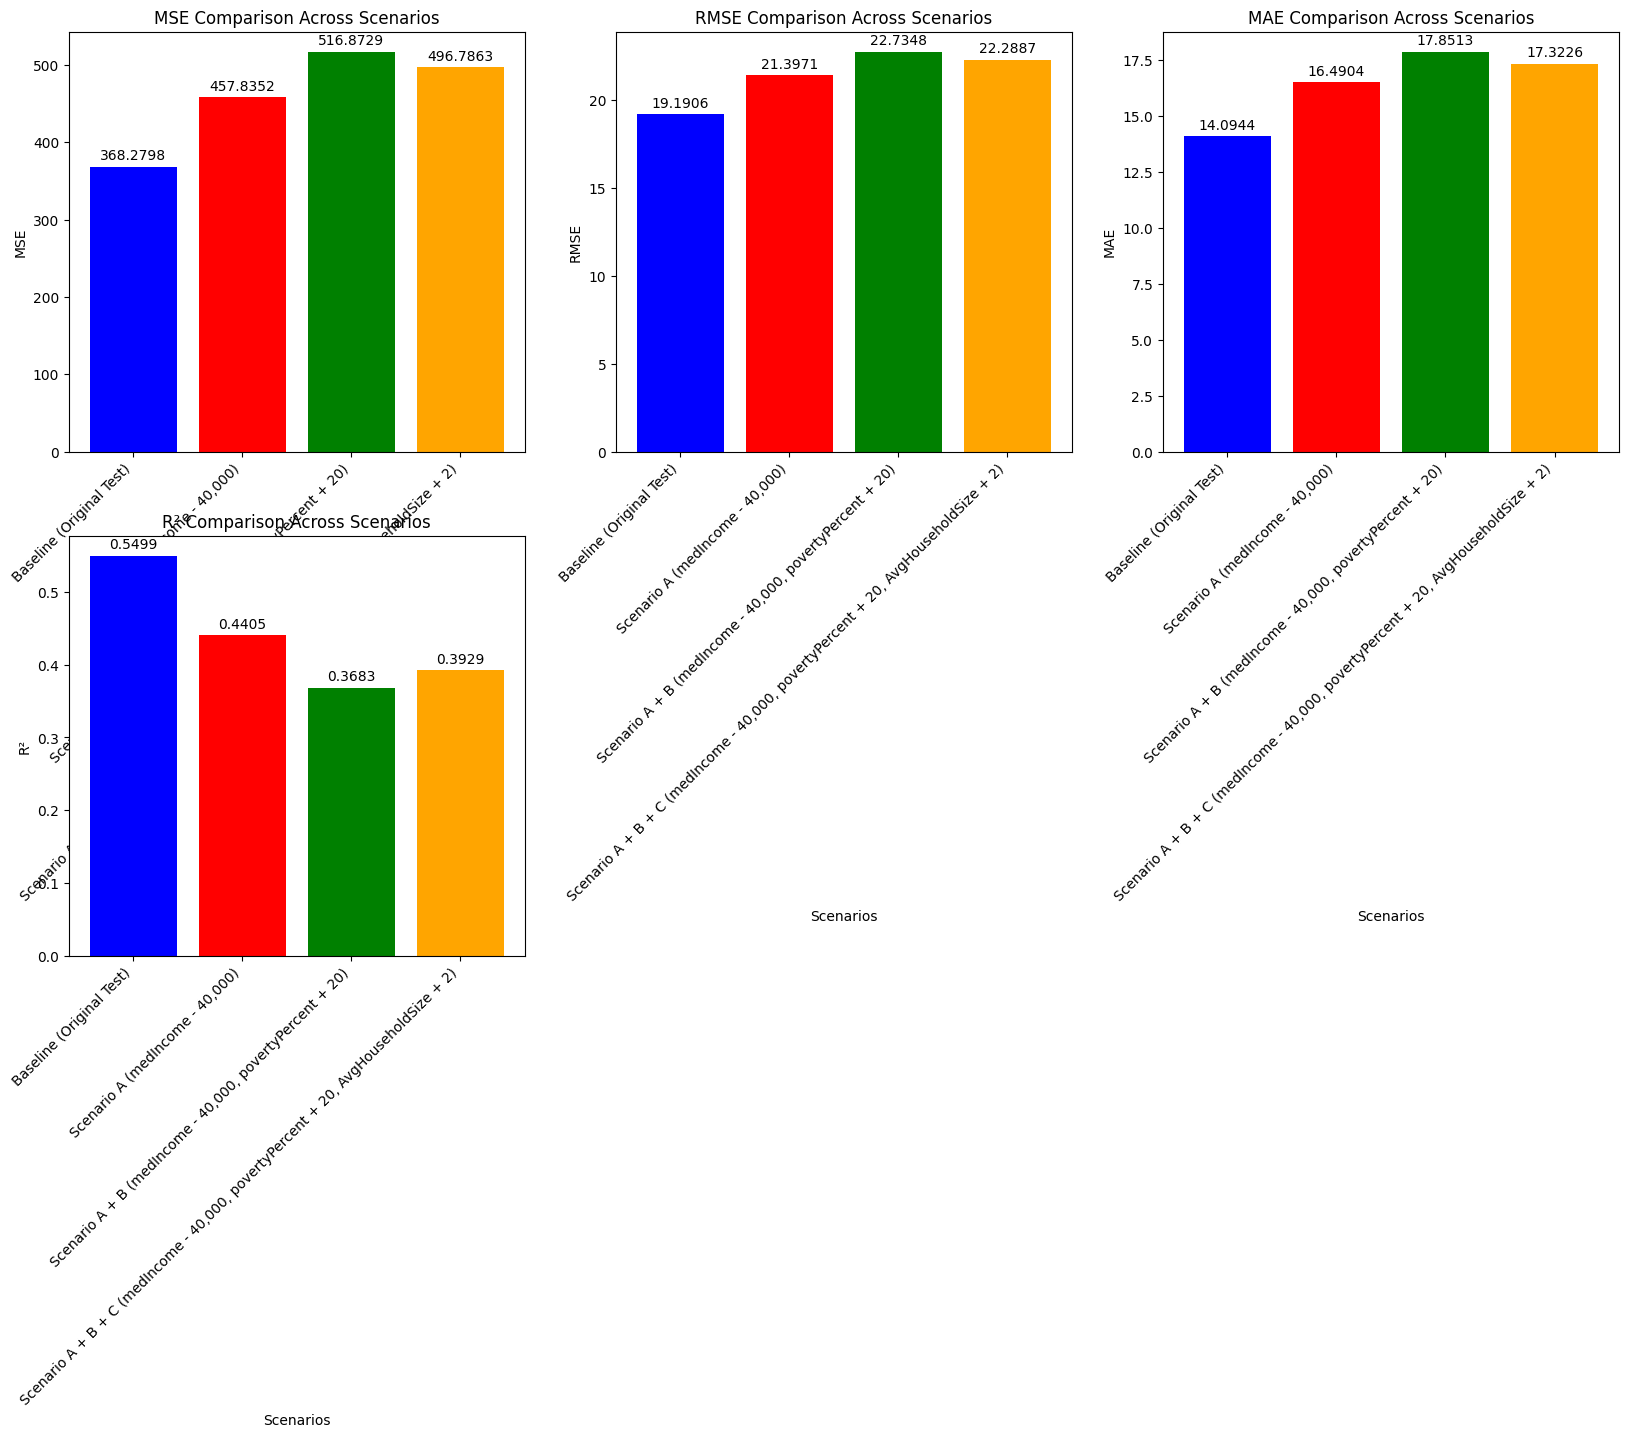

In [30]:
# Visualize the comparison
plt.figure(figsize=(20, 12))

# Performance metrics
metrics = ['MSE', 'RMSE', 'MAE', 'R²']
scenarios_list = [row['Scenario'] for row in comparison_data]

for i, metric in enumerate(metrics):
    plt.subplot(2, 3, i+1)
    values = [row[metric] for row in comparison_data]
    bars = plt.bar(range(len(scenarios_list)), values, color=['blue', 'red', 'green', 'orange'])
    plt.title(f'{metric} Comparison Across Scenarios')
    plt.xlabel('Scenarios')
    plt.ylabel(metric)
    plt.xticks(range(len(scenarios_list)), scenarios_list, rotation=45, ha='right')
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01, 
                f'{value:.4f}', ha='center', va='bottom')


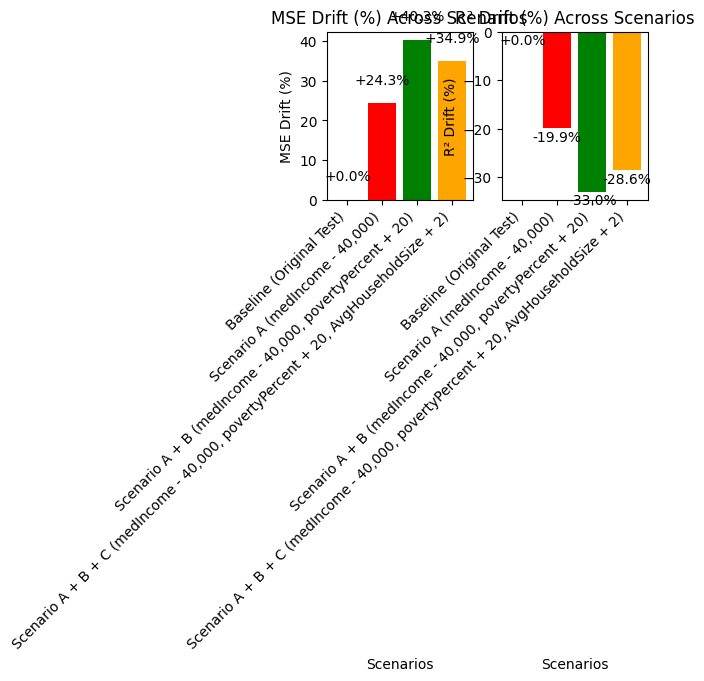

In [31]:
# Drift metrics
drift_metrics = ['MSE Drift (%)', 'R² Drift (%)']
for i, metric in enumerate(drift_metrics):
    plt.subplot(2, 3, i+5)
    values = [row[metric] for row in comparison_data]
    bars = plt.bar(range(len(scenarios_list)), values, color=['blue', 'red', 'green', 'orange'])
    plt.title(f'{metric} Across Scenarios')
    plt.xlabel('Scenarios')
    plt.ylabel(metric)
    plt.xticks(range(len(scenarios_list)), scenarios_list, rotation=45, ha='right')
    
    # Add value labels on bars
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (max(values) if max(values) > 0 else min(values))*0.1, 
                f'{value:+.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('scenario_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Key Findings
Baseline: RMSE 19.19, R² 0.55 – solid baseline performance.
Scenario A (Income ↓40k): RMSE increased to 21.40, R² dropped to 0.44 – lowering income reduced model accuracy by 24.3% in MSE and 19.9% in R².
Scenario A+B (Income ↓, Poverty ↑): RMSE rose further to 22.73, R² dropped to 0.37 – compounding income and poverty changes worsened performance by 40.3% in MSE and 33.0% in R².
Scenario A+B+C (Income ↓, Poverty ↑, HH Size ↑): RMSE slightly decreased to 22.29, R² improved modestly to 0.39 – accuracy remained significantly degraded versus baseline by 34.9% in MSE and 28.6% in R².
Drift Detection: All scenarios triggered significant drift alerts (>10% change), demonstrating the model's sensitivity to socioeconomic feature changes and the importance of continuous monitoring in production environments.


## Key Findings

**Baseline:** RMSE 19.19, R² 0.55 – solid baseline performance.

**Scenario A (Income ↓40k):** RMSE increased to 21.40, R² dropped to 0.44 – lowering income reduced model accuracy by 24.3% in MSE and 19.9% in R².

**Scenario A+B (Income ↓, Poverty ↑):** RMSE rose further to 22.73, R² dropped to 0.37 – compounding income and poverty changes worsened performance by 40.3% in MSE and 33.0% in R².

**Scenario A+B+C (Income ↓, Poverty ↑, HH Size ↑):** RMSE slightly decreased to 22.29, R² improved modestly to 0.39 – accuracy remained significantly degraded versus baseline by 34.9% in MSE and 28.6% in R².

**Drift Detection:** All scenarios triggered significant drift alerts (>10% change), demonstrating the model's sensitivity to socioeconomic feature changes and the importance of continuous monitoring in production environments.